In [34]:
%pip cache purge
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
%pip install pandas
%pip install timm
%pip install scikit-learn

Files removed: 2 (39 kB)
Directories removed: 0
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [35]:
import os
import shutil
from pathlib import Path
import pandas as pd
import shutil
import random

import sys
from PIL import Image
import torch
import torchvision
import timm
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import cohen_kappa_score
from collections import Counter
import torch.nn.functional as F
import torch.optim as optim

import torch.nn as nn


print("Using Python:", sys.executable)

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn tqdm timm

Using Python: /user/HS402/sm04533/Downloads/AMLv2/myenv/bin/python


In [36]:
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
Device count: 1
GPU: NVIDIA RTX A4000


In [37]:
# # Create main folder
# project_path = Path("./SplitDATA")
# project_path.mkdir(exist_ok=True)

# # Creating subfolders
# folders = [
#     "data/train/0", "data/train/1", "data/train/2", "data/train/3", "data/train/4",
#     "data/val/0", "data/val/1", "data/val/2", "data/val/3", "data/val/4",
#     "data/test/0", "data/test/1", "data/test/2", "data/test/3", "data/test/4",
#     "checkpoints",
#     "logs"
# ]

# for folder in folders:
#     (project_path / folder).mkdir(parents=True, exist_ok=True)
#     print(f"✓ Created: {folder}")

In [38]:


# # Read the labels CSV: image_name, DR_level (0, 1, 2, 3, or 4)
# try:
# 	labels_df = pd.read_csv("trainLabels.csv/trainLabels.csv")
# except PermissionError as e:
# 	print(f"PermissionError: {e}. Error file 'trainLabels.csv!! ")
# 	labels_df = pd.DataFrame()
# print("First 10 rows:")
# print(labels_df.head(10))

# print(f"\nTotal images: {len(labels_df)}")

# # Count how many of each class
# print("\nClass distribution:")
# print(labels_df['level'].value_counts().sort_index())

In [39]:
# #arranging the data into train, val and test sets

# # forLoad labels
# labels_df = pd.read_csv("trainLabels.csv/trainLabels.csv")

# # for Base paths
# images_raw_path = Path("train_images_compressed")
# data_path = Path("SplitDATA/data")

# # random seed for reproducibility
# random.seed(42)

# # Group images by class
# for class_level in range(5):  
#     ### 0, 1, 2, 3, 4
#     class_images = labels_df[labels_df['level'] == class_level]['image'].values
#     class_images = list(class_images)
    
#     random.shuffle(class_images)
    
#     # Calculate split
#     total = len(class_images)
#     train_size = int(total * 0.6)  # 60%
#     val_size = int(total * 0.2)    # 20%
    
#     train_imgs = class_images[:train_size]
#     val_imgs = class_images[train_size:train_size + val_size]
#     test_imgs = class_images[train_size + val_size:]
    
#     print(f"\nClass {class_level}:")
#     print(f"  Total: {total}")
#     print(f"  Train: {len(train_imgs)} (60%)")
#     print(f"  Val:   {len(val_imgs)} (20%)")
#     print(f"  Test:  {len(test_imgs)} (20%)")
    
#     # Copying train images
#     for img_name in train_imgs:
#         src = images_raw_path / f"{img_name}.jpg"
#         dst = data_path / "train" / str(class_level) / f"{img_name}.jpg"
        
#         if src.exists():
#             shutil.copy2(src, dst)
    
#     # Copying val images
#     for img_name in val_imgs:
#         src = images_raw_path / f"{img_name}.jpg"
#         dst = data_path / "val" / str(class_level) / f"{img_name}.jpg"
        
#         if src.exists():
#             shutil.copy2(src, dst)
    
#     # Copying test images
#     for img_name in test_imgs:
#         src = images_raw_path / f"{img_name}.jpg"
#         dst = data_path / "test" / str(class_level) / f"{img_name}.jpg"
        
#         if src.exists():
#             shutil.copy2(src, dst)

# print("\nImages organized!")

In [ ]:
# # to verify Data Organization
# from pathlib import Path
# data_path = Path("SplitDATA/data")
# class_names = ["No DR", "Mild", "Moderate"
# for split in ["train", "val", "test"]:, "Severe", "Proliferative DR"]

# print("Base path exists:", data_path.exists())
# print("Base path:", data_path)

#     print(f"\n{split.upper()} Set:")
#     total_split = 0

#     split_path = data_path / split
#     print(f"  Split path exists: {split_path.exists()} -> {split_path}")

#     for class_level in range(5):
#         class_dir = split_path / str(class_level)

#         if not class_dir.exists():
#             num_images = 0
#         else:
#             num_images = len(list(class_dir.glob("*.jpg"))) + len(list(class_dir.glob("*.jpeg"))) + len(list(class_dir.glob("*.png")))

#         total_split += num_images
#         print(f"  Class {class_level} ({class_names[class_level]:17s}): {num_images:5d} images")

#     print(f"  {'-' * 40}")
#     print(f"  Total {split}: {total_split} images")

# ##print("\nOverall verification complete!")

In [ ]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#DATA_DIR = Path("/kaggle/working/SplitDATA") / "data"
DATA_DIR = Path("SplitDATA") / "data"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

MODEL_NAME = "deit_small_distilled_patch16_224"
MODEL_NAME_BASELINE = "deit_small_patch16_224"

TEACHER_NAME = "regnety_160"

NUM_EPOCHS = 12
TEACHER_EPOCHS = 12
LEARNING_RATE = 1e-4
ALPHA = 0.3
TAU = 2.0
# LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.05
# ALPHA = 0.5
# TAU = 1.0
PATIENCE = 5


In [ ]:
class DRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.images = []
        self.labels = []

        for label in range(NUM_CLASSES):
            class_dir = self.root_dir / str(label)
            if class_dir.exists():
                for ext in ["*.jpg", "*.jpeg", "*.png"]:
                    for img_path in class_dir.glob(ext):
                        self.images.append(str(img_path))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


train_dataset = DRDataset(TRAIN_DIR, transform=train_transform)
val_dataset = DRDataset(VAL_DIR, transform=val_test_transform)
test_dataset = DRDataset(TEST_DIR, transform=val_test_transform)

print(f"Train dataset: {len(train_dataset)} images")
print(f"Val dataset:   {len(val_dataset)} images")
print(f"Test dataset:  {len(test_dataset)} images")

#imbalance cls
# class_counts = Counter(train_dataset.labels)
# print("Class counts:", class_counts)

# from sklearn.utils.class_weight import compute_class_weight

# weights = compute_class_weight(
#     class_weight="balanced",
#     classes=np.arange(5),
#     y=train_dataset.labels
# )
# class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

# print("Class weights:", class_weights)
# ============================================================
# CLASS DISTRIBUTION CHECK
# ============================================================

class_counts = Counter(train_dataset.labels)
print("Class counts:", class_counts)

# IMPORTANT:Previous class weights caused the model to overpredict class 3 and 4.

class_weights = None

print("Class weights disabled to prevent severe-class overprediction.")


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("\nData loaders ready!")

Train dataset: 21074 images
Val dataset:   7026 images
Test dataset:  7026 images
Class counts: Counter({0: 15491, 2: 3184, 1: 1455, 3: 523, 4: 421})
Class weights: tensor([ 0.2721,  2.8968,  1.3237,  8.0589, 10.0114], device='cuda:0')

Data loaders ready!


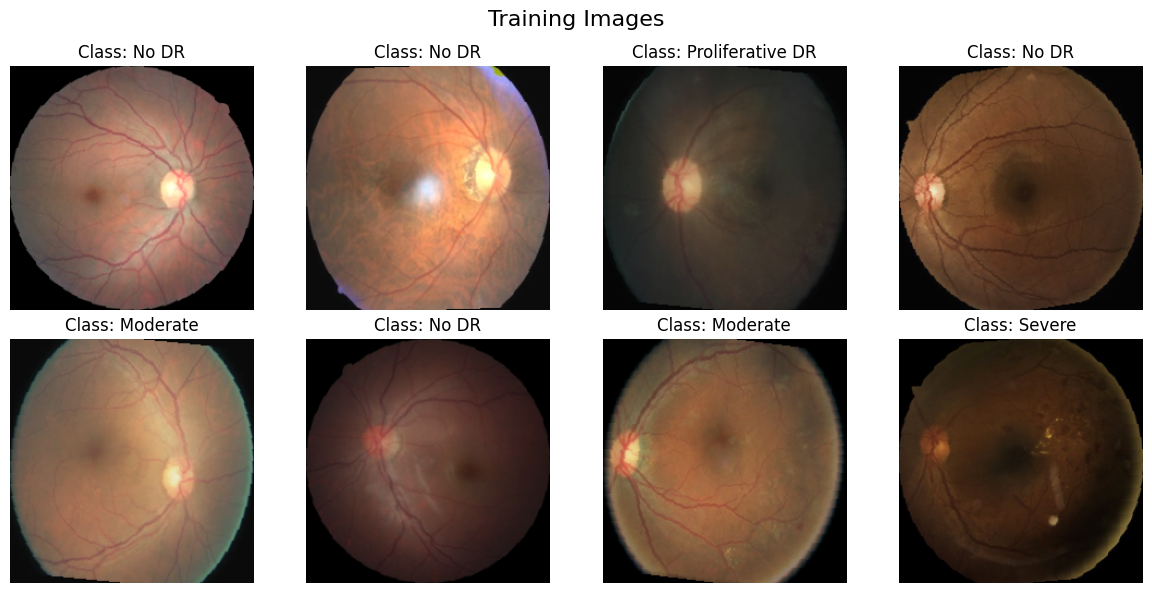

In [43]:
# Visualize Images
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# Get a batch of images
images, labels = next(iter(train_loader))

# Denormalize images for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
images_display = images[:8] * std + mean  # Undo normalization

# Plot
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Training Images', fontsize=16)

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

for idx, ax in enumerate(axes.flat):
    img = images_display[idx].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)  # Clip to [0, 1]
    
    ax.imshow(img)
    ax.set_title(f"Class: {class_names[labels[idx].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('SplitDATA\\logs\\sample_images.png', dpi=150)
plt.show()

#print(" Images displayed!")

In [44]:
# creating FULL DeiT student model
student_model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=0.0,
    drop_path_rate=0.1
).to(DEVICE)

total_params = sum(p.numel() for p in student_model.parameters())
trainable_params = sum(p.numel() for p in student_model.parameters() if p.requires_grad)

print(f"Student model: {MODEL_NAME}")
print(f"Total params: {total_params/1e6:.2f}M")
print(f"Trainable params: {trainable_params/1e6:.2f}M")

Student model: deit_small_distilled_patch16_224
Total params: 21.67M
Trainable params: 21.67M


In [ ]:
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, cohen_kappa_score

os.makedirs("SplitDATA/checkpoints", exist_ok=True)
os.makedirs("SplitDATA/logs", exist_ok=True)

teacher_ckpt = "SplitDATA/checkpoints/teacher_regnety160_best.pth"
teacher_log_path = "SplitDATA/logs/teacher_training_log.txt"

teacher_model = timm.create_model(
    TEACHER_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
).to(DEVICE)

def train_teacher_if_needed(model, train_loader, val_loader, ckpt_path, epochs=TEACHER_EPOCHS):

    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        print("Loaded existing teacher checkpoint")
        return model

    criterion_teacher = nn.CrossEntropyLoss(
        #weight=class_weights,
        label_smoothing=0.1
    )

    optimizer_teacher = optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=WEIGHT_DECAY
    )

    scheduler_teacher = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_teacher,
        T_max=epochs,
        eta_min=1e-6
    )

    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

    best_val_qwk = -1.0
    best_val_f1 = -1.0

    with open(teacher_log_path, "w") as f:
        f.write("====================================================\n")
        f.write("Teacher Training Log - RegNetY-160\n")
        f.write("====================================================\n\n")

    for epoch in range(epochs):

        model.train()
        running_loss = 0.0
        train_preds, train_labels = [], []

        for images, labels in tqdm(train_loader, desc=f"Teacher Train {epoch+1}/{epochs}", leave=False):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer_teacher.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion_teacher(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer_teacher)
            scaler.update()

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)
            train_preds.extend(preds.detach().cpu().numpy())
            train_labels.extend(labels.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average="macro")

        model.eval()

        val_preds, val_labels = [], []
        val_loss = 0.0

        with torch.no_grad():

            for images, labels in tqdm(val_loader, desc=f"Teacher Val {epoch+1}/{epochs}", leave=False):

                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)

                outputs = model(images)
                loss = criterion_teacher(outputs, labels)

                val_loss += loss.item()

                preds = outputs.argmax(dim=1)

                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader)

        val_acc = accuracy_score(val_labels, val_preds)
        val_bal_acc = balanced_accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average="macro")
        val_qwk = cohen_kappa_score(val_labels, val_preds, weights="quadratic")

        scheduler_teacher.step()

        epoch_log = (
            f"\n====================================================\n"
            f"Teacher Epoch {epoch+1}/{epochs}\n"
            f"====================================================\n"
            f"Train Loss          : {train_loss:.4f}\n"
            f"Train Accuracy      : {train_acc*100:.2f}%\n"
            f"Train Macro-F1      : {train_f1:.4f}\n\n"
            f"Val Loss            : {val_loss:.4f}\n"
            f"Val Accuracy        : {val_acc*100:.2f}%\n"
            f"Val Balanced Acc    : {val_bal_acc:.4f}\n"
            f"Val Macro-F1        : {val_f1:.4f}\n"
            f"Val QWK             : {val_qwk:.4f}\n"
        )

        print(epoch_log)

        with open(teacher_log_path, "a") as f:
            f.write(epoch_log)

        # Save best teacher using QWK
        if val_qwk > best_val_qwk:

            best_val_qwk = val_qwk
            best_val_f1 = val_f1

            torch.save(model.state_dict(), ckpt_path)

            msg = (
                f"\nBest teacher saved\n"
                f"Best Val QWK      : {best_val_qwk:.4f}\n"
                f"Val Macro-F1      : {best_val_f1:.4f}\n"
            )

            print(msg)

            with open(teacher_log_path, "a") as f:
                f.write(msg)

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    final_msg = (
        f"\nTeacher ready\n"
        f"Best Val QWK      : {best_val_qwk:.4f}\n"
        f"Best Val Macro-F1 : {best_val_f1:.4f}\n"
    )

    print(final_msg)

    with open(teacher_log_path, "a") as f:
        f.write(final_msg)

    return model

teacher_model = train_teacher_if_needed(
    teacher_model,
    train_loader,
    val_loader,
    teacher_ckpt,
    epochs=TEACHER_EPOCHS
)

teacher_model.eval()

for p in teacher_model.parameters():
    p.requires_grad = False

print("Teacher loaded and frozen for distillation.")


Teacher Epoch 1/12
Train Loss          : 2.2395
Train Accuracy      : 2.42%
Train Macro-F1      : 0.0258

Val Loss            : 3.5133
Val Accuracy        : 2.09%
Val Balanced Acc    : 0.2029
Val Macro-F1        : 0.0163
Val QWK             : -0.0001


Best teacher saved
Best Val QWK      : -0.0001
Val Macro-F1      : 0.0163




Teacher Epoch 2/12
Train Loss          : 2.2358
Train Accuracy      : 2.28%
Train Macro-F1      : 0.0214

Val Loss            : 3.5487
Val Accuracy        : 3.13%
Val Balanced Acc    : 0.2046
Val Macro-F1        : 0.0350
Val QWK             : 0.0140


Best teacher saved
Best Val QWK      : 0.0140
Val Macro-F1      : 0.0350




Teacher Epoch 3/12
Train Loss          : 2.2320
Train Accuracy      : 2.40%
Train Macro-F1      : 0.0239

Val Loss            : 3.5130
Val Accuracy        : 2.08%
Val Balanced Acc    : 0.2005
Val Macro-F1        : 0.0156
Val QWK             : 0.0029




Teacher Epoch 4/12
Train Loss          : 2.2229
Train Accuracy      : 2.15%
Train Macro-F1      : 0.0167

Val Loss            : 3.5119
Val Accuracy        : 2.01%
Val Balanced Acc    : 0.1897
Val Macro-F1        : 0.0160
Val QWK             : 0.0005




Teacher Epoch 5/12
Train Loss          : 2.2336
Train Accuracy      : 2.12%
Train Macro-F1      : 0.0167

Val Loss            : 3.5097
Val Accuracy        : 2.49%
Val Balanced Acc    : 0.2217
Val Macro-F1        : 0.0192
Val QWK             : -0.0006



...


Teacher Epoch 9/12
Train Loss          : 2.2236
Train Accuracy      : 2.61%
Train Macro-F1      : 0.0220

Val Loss            : 3.5168
Val Accuracy        : 2.45%
Val Balanced Acc    : 0.2217
Val Macro-F1        : 0.0221
Val QWK             : -0.0021




Teacher Epoch 10/12
Train Loss          : 2.1979
Train Accuracy      : 2.57%
Train Macro-F1      : 0.0224

Val Loss            : 3.5036
Val Accuracy        : 3.02%
Val Balanced Acc    : 0.2408
Val Macro-F1        : 0.0248
Val QWK             : -0.0008




Teacher Epoch 11/12
Train Loss          : 2.2091
Train Accuracy      : 2.66%
Train Macro-F1      : 0.0233

Val Loss            : 3.5128
Val Accuracy        : 2.73%
Val Balanced Acc    : 0.2404
Val Macro-F1        : 0.0215
Val QWK             : -0.0034



/tmp/ipykernel_58974/1502091778.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))



Teacher Epoch 12/12
Train Loss          : 2.2109
Train Accuracy      : 2.73%
Train Macro-F1      : 0.0224

Val Loss            : 3.5145
Val Accuracy        : 2.66%
Val Balanced Acc    : 0.2412
Val Macro-F1        : 0.0224
Val QWK             : -0.0037


Teacher ready
Best Val QWK      : 0.0140
Best Val Macro-F1 : 0.0350

Teacher loaded and frozen for distillation.


In [ ]:

import torch.optim as optim
# Distillation training setup
criterion_cls = nn.CrossEntropyLoss(
    #weight=class_weights,
    label_smoothing=0.1
)

# KL divergence for soft distillation
criterion_dist = nn.KLDivLoss(reduction="batchmean")

optimizer = optim.AdamW(
    student_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

print(f"ALPHA = {ALPHA}, TAU = {TAU}")

ALPHA = 0.5, TAU = 1.0


In [47]:

# DeiT WITHOUT DISTILLATION/ Uses normal DeiT, no teacher

baseline_model = timm.create_model(
    MODEL_NAME_BASELINE,
    pretrained=True,
    num_classes=5
).to(DEVICE)

baseline_optimizer = torch.optim.AdamW(
    baseline_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

baseline_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    baseline_optimizer,
    T_max=NUM_EPOCHS
)

baseline_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

best_baseline_qwk = -1.0
baseline_patience_counter = 0

baseline_log_path = "SplitDATA/logs/deit_without_distillation_log.txt"

with open(baseline_log_path, "w") as f:
    f.write("=====================================================\n")
    f.write("DeiT WITHOUT Distillation Training Log\n")
    f.write("=====================================================\n\n")
    f.write(f"Model: {MODEL_NAME_BASELINE}\n")
    f.write("Teacher Used: No\n")
    f.write("Loss: CrossEntropy only\n\n")

for epoch in range(1, NUM_EPOCHS + 1):

    baseline_model.train()

    train_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"No-Distill Epoch {epoch} Train", leave=False):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        baseline_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):

            logits = baseline_model(images)
            loss = criterion_cls(logits, labels)

        baseline_scaler.scale(loss).backward()
        baseline_scaler.step(baseline_optimizer)
        baseline_scaler.update()

        train_loss += loss.item()

        preds = logits.argmax(dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(labels.detach().cpu().numpy())

    train_loss /= len(train_loader)

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    # ========================================================
    # VALIDATION
    # ========================================================

    baseline_model.eval()

    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():

        for images, labels in tqdm(val_loader, desc=f"No-Distill Epoch {epoch} Val", leave=False):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits = baseline_model(images)
            loss = criterion_cls(logits, labels)

            val_loss += loss.item()

            preds = logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc = accuracy_score(val_labels, val_preds)
    val_bal_acc = balanced_accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")
    val_qwk = cohen_kappa_score(val_labels, val_preds, weights="quadratic")

    baseline_scheduler.step()

    epoch_log = (
        f"\nEpoch {epoch:02d}/{NUM_EPOCHS}\n"
        f"Train Loss          : {train_loss:.4f}\n"
        f"Train Accuracy      : {train_acc*100:.2f}%\n"
        f"Train Macro-F1      : {train_f1:.4f}\n"
        f"Validation Loss     : {val_loss:.4f}\n"
        f"Validation Accuracy : {val_acc*100:.2f}%\n"
        f"Validation Bal Acc  : {val_bal_acc:.4f}\n"
        f"Validation Macro-F1 : {val_f1:.4f}\n"
        f"Validation QWK      : {val_qwk:.4f}\n"
    )

    print(epoch_log)

    with open(baseline_log_path, "a") as f:
        f.write(epoch_log)

    if val_qwk > best_baseline_qwk:

        best_baseline_qwk = val_qwk
        baseline_patience_counter = 0

        torch.save(
            baseline_model.state_dict(),
            "SplitDATA/checkpoints/best_deit_without_distillation.pth"
        )

        msg = f"\nBest no-distillation DeiT saved | Val QWK: {val_qwk:.4f}\n"
        print(msg)

        with open(baseline_log_path, "a") as f:
            f.write(msg)

    else:

        baseline_patience_counter += 1

        if baseline_patience_counter >= PATIENCE:
            stop_msg = f"\nEarly stopping at epoch {epoch}\n"
            print(stop_msg)

            with open(baseline_log_path, "a") as f:
                f.write(stop_msg)

            break

print(f"DeiT without distillation complete | Best Val QWK: {best_baseline_qwk:.4f}")


Epoch 01/12
Train Loss          : 2.2466
Train Accuracy      : 2.66%
Train Macro-F1      : 0.0286
Validation Loss     : 3.5128
Validation Accuracy : 1.96%
Validation Bal Acc  : 0.2000
Validation Macro-F1 : 0.0077
Validation QWK      : 0.0000


Best no-distillation DeiT saved | Val QWK: 0.0000




Epoch 02/12
Train Loss          : 2.2327
Train Accuracy      : 2.54%
Train Macro-F1      : 0.0198
Validation Loss     : 3.5152
Validation Accuracy : 1.95%
Validation Bal Acc  : 0.1982
Validation Macro-F1 : 0.0093
Validation QWK      : 0.0005


Best no-distillation DeiT saved | Val QWK: 0.0005




Epoch 03/12
Train Loss          : 2.2190
Train Accuracy      : 2.51%
Train Macro-F1      : 0.0190
Validation Loss     : 3.5903
Validation Accuracy : 3.23%
Validation Bal Acc  : 0.2141
Validation Macro-F1 : 0.0334
Validation QWK      : 0.0051


Best no-distillation DeiT saved | Val QWK: 0.0051




Epoch 04/12
Train Loss          : 2.2303
Train Accuracy      : 2.79%
Train Macro-F1      : 0.0218
Validation Loss     : 3.4743
Validation Accuracy : 2.06%
Validation Bal Acc  : 0.2046
Validation Macro-F1 : 0.0164
Validation QWK      : -0.0001




Epoch 05/12
Train Loss          : 2.2132
Train Accuracy      : 2.65%
Train Macro-F1      : 0.0225
Validation Loss     : 3.5140
Validation Accuracy : 2.45%
Validation Bal Acc  : 0.2268
Validation Macro-F1 : 0.0208
Validation QWK      : -0.0026



...


Epoch 08/12
Train Loss          : 2.2150
Train Accuracy      : 2.86%
Train Macro-F1      : 0.0271
Validation Loss     : 3.4775
Validation Accuracy : 5.57%
Validation Bal Acc  : 0.2189
Validation Macro-F1 : 0.0378
Validation QWK      : 0.0105


Best no-distillation DeiT saved | Val QWK: 0.0105




Epoch 09/12
Train Loss          : 2.2065
Train Accuracy      : 4.90%
Train Macro-F1      : 0.0471
Validation Loss     : 3.4866
Validation Accuracy : 10.19%
Validation Bal Acc  : 0.2416
Validation Macro-F1 : 0.0767
Validation QWK      : 0.0259


Best no-distillation DeiT saved | Val QWK: 0.0259




Epoch 10/12
Train Loss          : 2.1959
Train Accuracy      : 4.19%
Train Macro-F1      : 0.0445
Validation Loss     : 3.5310
Validation Accuracy : 3.02%
Validation Bal Acc  : 0.2569
Validation Macro-F1 : 0.0328
Validation QWK      : -0.0003




Epoch 11/12
Train Loss          : 2.1870
Train Accuracy      : 4.56%
Train Macro-F1      : 0.0517
Validation Loss     : 3.4975
Validation Accuracy : 4.65%
Validation Bal Acc  : 0.2696
Validation Macro-F1 : 0.0530
Validation QWK      : 0.0047




Epoch 12/12
Train Loss          : 2.1857
Train Accuracy      : 4.34%
Train Macro-F1      : 0.0512
Validation Loss     : 3.5273
Validation Accuracy : 4.07%
Validation Bal Acc  : 0.2564
Validation Macro-F1 : 0.0480
Validation QWK      : 0.0026

DeiT without distillation complete | Best Val QWK: 0.0259


In [ ]:
# Full DeiT distillation training

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    cohen_kappa_score
)

def unpack_student_outputs(outputs):
    if isinstance(outputs, (tuple, list)) and len(outputs) == 2:
        return outputs[0], outputs[1]
    return outputs, outputs

log_path = "SplitDATA/logs/training_log.txt"
os.makedirs(os.path.dirname(log_path), exist_ok=True)

with open(log_path, "w") as f:
    f.write("=========================================================\n")
    f.write("Diabetic Retinopathy DeiT Distillation Training Log\n")
    f.write("=========================================================\n\n")

    f.write(f"Model: {MODEL_NAME}\n")
    f.write(f"Image Size: {IMG_SIZE}\n")
    f.write(f"Batch Size: {BATCH_SIZE}\n")
    f.write(f"Learning Rate: {LEARNING_RATE}\n")
    f.write(f"Epochs: {NUM_EPOCHS}\n")
    f.write(f"Patience: {PATIENCE}\n")
    f.write(f"Temperature TAU: {TAU}\n")
    f.write(f"Distillation Alpha: {ALPHA}\n\n")

    f.write("=========================================================\n")
    f.write("EPOCH RESULTS\n")
    f.write("=========================================================\n")

best_val_qwk = -1.0
best_val_f1 = -1.0
patience_counter = 0

# New PyTorch AMP syntax
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_bal_acc": [],
    "val_f1": [],
    "val_qwk": []
}

for epoch in range(1, NUM_EPOCHS + 1):

    student_model.train()
    teacher_model.eval()

    train_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch} Train", leave=False):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.no_grad():
            teacher_logits = teacher_model(images)

        # ====================================================
        # MIXED PRECISION FOR TRAINING
        # ====================================================

        with torch.amp.autocast("cuda", enabled=use_amp):

            student_outputs = student_model(images)
            cls_logits, dist_logits = unpack_student_outputs(student_outputs)

            loss_cls = criterion_cls(cls_logits, labels)

            loss_dist = criterion_dist(
                F.log_softmax(dist_logits / TAU, dim=1),
                F.softmax(teacher_logits / TAU, dim=1)
            ) * (TAU ** 2)

            loss = (1 - ALPHA) * loss_cls + ALPHA * loss_dist

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        # scaler.scale(loss).backward()
        # scaler.step(optimizer)
        # scaler.update()

        train_loss += loss.item()

        preds = ((cls_logits + dist_logits) / 2.0).argmax(dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(labels.detach().cpu().numpy())

    train_loss /= len(train_loader)

    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    # ========================================================
    # VALIDATION
    # ========================================================

    student_model.eval()

    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():

        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch} Val", leave=False):

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            teacher_logits = teacher_model(images)

            student_outputs = student_model(images)
            cls_logits, dist_logits = unpack_student_outputs(student_outputs)

            loss_cls = criterion_cls(cls_logits, labels)

            loss_dist = criterion_dist(
                F.log_softmax(dist_logits / TAU, dim=1),
                F.softmax(teacher_logits / TAU, dim=1)
            ) * (TAU ** 2)

            loss = (1 - ALPHA) * loss_cls + ALPHA * loss_dist

            val_loss += loss.item()

            final_logits = (cls_logits + dist_logits) / 2.0
            preds = final_logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc = accuracy_score(val_labels, val_preds)
    val_bal_acc = balanced_accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    val_qwk = cohen_kappa_score(
        val_labels,
        val_preds,
        weights="quadratic"
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_bal_acc"].append(val_bal_acc)
    history["val_f1"].append(val_f1)
    history["val_qwk"].append(val_qwk)

    epoch_log = (
        f"\n=========================================================\n"
        f"Epoch {epoch:02d}/{NUM_EPOCHS}\n"
        f"=========================================================\n"
        f"Train Loss           : {train_loss:.4f}\n"
        f"Train Accuracy       : {train_acc*100:.2f}%\n"
        f"Train Macro-F1       : {train_f1:.4f}\n\n"
        f"Validation Loss      : {val_loss:.4f}\n"
        f"Validation Accuracy  : {val_acc*100:.2f}%\n"
        f"Validation Bal Acc   : {val_bal_acc:.4f}\n"
        f"Validation Macro-F1  : {val_f1:.4f}\n"
        f"Validation QWK       : {val_qwk:.4f}\n"
    )

    print(epoch_log)

    with open(log_path, "a") as f:
        f.write(epoch_log)

    if val_qwk > best_val_qwk:

        best_val_qwk = val_qwk
        best_val_f1 = val_f1
        patience_counter = 0

        torch.save(
            student_model.state_dict(),
            "SplitDATA/checkpoints/best_distilled_deit_model.pth"
        )

        best_msg = (
            f"\nBEST MODEL SAVED\n"
            f"Validation QWK      : {val_qwk:.4f}\n"
            f"Validation Macro-F1 : {val_f1:.4f}\n"
        )

        print(best_msg)

        with open(log_path, "a") as f:
            f.write(best_msg)

    else:

        patience_counter += 1

        patience_msg = (
            f"\nNo QWK improvement. "
            f"Patience Counter: {patience_counter}/{PATIENCE}\n"
        )

        print(patience_msg)

        with open(log_path, "a") as f:
            f.write(patience_msg)

        if patience_counter >= PATIENCE:

            stop_msg = f"\nEarly stopping at epoch {epoch}\n"

            print(stop_msg)

            with open(log_path, "a") as f:
                f.write(stop_msg)

            break

final_summary = (
    f"\n=========================================================\n"
    f"TRAINING COMPLETE\n"
    f"=========================================================\n"
    f"Best Validation QWK      : {best_val_qwk:.4f}\n"
    f"Best Validation Macro-F1 : {best_val_f1:.4f}\n"
)

print(final_summary)

with open(log_path, "a") as f:
    f.write(final_summary)


Epoch 01/12
Train Loss           : 1.1362
Train Accuracy       : 2.63%
Train Macro-F1       : 0.0313

Validation Loss      : 1.7578
Validation Accuracy  : 2.43%
Validation Bal Acc   : 0.1841
Validation Macro-F1  : 0.0304
Validation QWK       : -0.0005


BEST MODEL SAVED
Validation QWK      : -0.0005
Validation Macro-F1 : 0.0304




Epoch 02/12
Train Loss           : 1.1252
Train Accuracy       : 2.41%
Train Macro-F1       : 0.0281

Validation Loss      : 1.7718
Validation Accuracy  : 2.50%
Validation Bal Acc   : 0.2086
Validation Macro-F1  : 0.0265
Validation QWK       : -0.0006


No QWK improvement. Patience Counter: 1/5




Epoch 03/12
Train Loss           : 1.1192
Train Accuracy       : 2.45%
Train Macro-F1       : 0.0280

Validation Loss      : 1.7699
Validation Accuracy  : 1.96%
Validation Bal Acc   : 0.2000
Validation Macro-F1  : 0.0077
Validation QWK       : 0.0000


BEST MODEL SAVED
Validation QWK      : 0.0000
Validation Macro-F1 : 0.0077




Epoch 04/12
Train Loss           : 1.1232
Train Accuracy       : 2.38%
Train Macro-F1       : 0.0272

Validation Loss      : 1.7507
Validation Accuracy  : 2.35%
Validation Bal Acc   : 0.2036
Validation Macro-F1  : 0.0178
Validation QWK       : -0.0064


No QWK improvement. Patience Counter: 1/5




Epoch 05/12
Train Loss           : 1.1170
Train Accuracy       : 2.53%
Train Macro-F1       : 0.0281

Validation Loss      : 1.7690
Validation Accuracy  : 2.04%
Validation Bal Acc   : 0.2004
Validation Macro-F1  : 0.0155
Validation QWK       : 0.0007


BEST MODEL SAVED
Validation QWK      : 0.0007
Validation Macro-F1 : 0.0155



...


Epoch 08/12
Train Loss           : 1.1166
Train Accuracy       : 2.89%
Train Macro-F1       : 0.0343

Validation Loss      : 1.7622
Validation Accuracy  : 2.06%
Validation Bal Acc   : 0.2039
Validation Macro-F1  : 0.0163
Validation QWK       : 0.0005


No QWK improvement. Patience Counter: 2/5




Epoch 09/12
Train Loss           : 1.1144
Train Accuracy       : 3.14%
Train Macro-F1       : 0.0376

Validation Loss      : 1.7673
Validation Accuracy  : 2.92%
Validation Bal Acc   : 0.2354
Validation Macro-F1  : 0.0344
Validation QWK       : 0.0008


No QWK improvement. Patience Counter: 3/5




Epoch 10/12
Train Loss           : 1.1077
Train Accuracy       : 3.37%
Train Macro-F1       : 0.0417

Validation Loss      : 1.7592
Validation Accuracy  : 3.02%
Validation Bal Acc   : 0.2557
Validation Macro-F1  : 0.0319
Validation QWK       : 0.0044


No QWK improvement. Patience Counter: 4/5




Epoch 11/12
Train Loss           : 1.0994
Train Accuracy       : 3.93%
Train Macro-F1       : 0.0469

Validation Loss      : 1.7891
Validation Accuracy  : 3.84%
Validation Bal Acc   : 0.2709
Validation Macro-F1  : 0.0451
Validation QWK       : 0.0204


BEST MODEL SAVED
Validation QWK      : 0.0204
Validation Macro-F1 : 0.0451




Epoch 12/12
Train Loss           : 1.0928
Train Accuracy       : 4.29%
Train Macro-F1       : 0.0507

Validation Loss      : 1.7721
Validation Accuracy  : 3.32%
Validation Bal Acc   : 0.2577
Validation Macro-F1  : 0.0382
Validation QWK       : 0.0088


No QWK improvement. Patience Counter: 1/5


TRAINING COMPLETE
Best Validation QWK      : 0.0204
Best Validation Macro-F1 : 0.0451



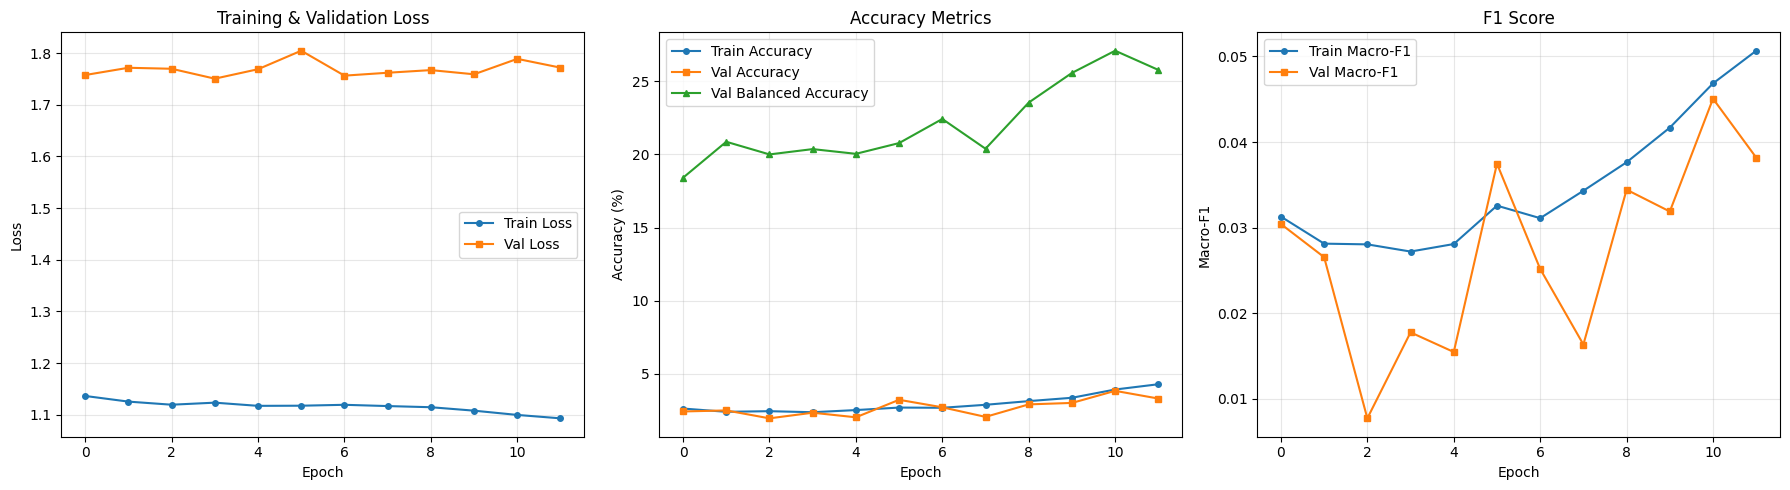

In [49]:
# plot training results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([x * 100 for x in history['train_acc']], label='Train Accuracy', marker='o', markersize=4)
axes[1].plot([x * 100 for x in history['val_acc']], label='Val Accuracy', marker='s', markersize=4)
axes[1].plot([x * 100 for x in history['val_bal_acc']], label='Val Balanced Accuracy', marker='^', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['train_f1'], label='Train Macro-F1', marker='o', markersize=4)
axes[2].plot(history['val_f1'], label='Val Macro-F1', marker='s', markersize=4)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro-F1')
axes[2].set_title('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('SplitDATA/logs/training_curves_distilled_deit.png', dpi=150)
plt.show()

In [55]:
# ============================================================
# DEBUG CHECK: DATA + PREDICTIONS
# ============================================================

from collections import Counter
import os

print("Train labels:", Counter(train_dataset.labels))
print("Val labels:  ", Counter(val_dataset.labels))
print("Test labels: ", Counter(test_dataset.labels))

print("\nCheckpoint exists?")
print("Without distillation:", os.path.exists("SplitDATA/checkpoints/best_deit_without_distillation.pth"))
print("With distillation:   ", os.path.exists("SplitDATA/checkpoints/best_distilled_deit_model.pth"))
print("Teacher:             ", os.path.exists("SplitDATA/checkpoints/teacher_regnety160_best.pth"))

Train labels: Counter({0: 15491, 2: 3184, 1: 1455, 3: 523, 4: 421})
Val labels:   Counter({0: 5165, 2: 1050, 1: 495, 3: 178, 4: 138})
Test labels:  Counter({0: 5154, 2: 1058, 1: 493, 3: 172, 4: 149})

Checkpoint exists?
Without distillation: True
With distillation:    True
Teacher:              True


In [50]:
# ============================================================
# TEST BOTH MODELS:
# 1. DeiT WITHOUT Distillation
# 2. DeiT WITH Distillation
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

os.makedirs("SplitDATA/logs", exist_ok=True)

def unpack_student_outputs(outputs):
    if isinstance(outputs, (tuple, list)) and len(outputs) == 2:
        return outputs[0], outputs[1]
    return outputs, outputs


def evaluate_and_save_test_results(
    model,
    test_loader,
    model_name,
    checkpoint_path,
    save_path,
    is_distilled=False
):
    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device
        )
    )

    model.eval()

    test_preds = []
    test_labels = []
    test_probs = []

    print(f"\nTesting: {model_name}")

    with torch.no_grad():

        for images, labels in tqdm(test_loader, desc=f"Testing {model_name}"):

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            if is_distilled:
                cls_logits, dist_logits = unpack_student_outputs(outputs)
                final_logits = (cls_logits + dist_logits) / 2.0
            else:
                final_logits = outputs

            probs = F.softmax(final_logits, dim=1)
            preds = final_logits.argmax(dim=1)

            test_probs.extend(probs.cpu().numpy())
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())

    test_probs = np.array(test_probs)
    test_preds = np.array(test_preds)
    test_labels = np.array(test_labels)

    cm = confusion_matrix(test_labels, test_preds)

    test_acc = accuracy_score(test_labels, test_preds)
    test_bal_acc = balanced_accuracy_score(test_labels, test_preds)
    macro_precision = precision_score(test_labels, test_preds, average="macro", zero_division=0)
    macro_recall = recall_score(test_labels, test_preds, average="macro", zero_division=0)
    macro_f1 = f1_score(test_labels, test_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(test_labels, test_preds, average="weighted", zero_division=0)
    qwk = cohen_kappa_score(test_labels, test_preds, weights="quadratic")
    mcc = matthews_corrcoef(test_labels, test_preds)

    try:
        multiclass_auc = roc_auc_score(
            test_labels,
            test_probs,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        multiclass_auc = None

    report = classification_report(
        test_labels,
        test_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
    )

    result_text = (
        f"====================================================\n"
        f"TEST RESULTS - {model_name}\n"
        f"====================================================\n\n"
        f"Checkpoint                : {checkpoint_path}\n\n"
        f"Accuracy                  : {test_acc:.4f}\n"
        f"Balanced Accuracy         : {test_bal_acc:.4f}\n"
        f"Macro Precision           : {macro_precision:.4f}\n"
        f"Macro Recall              : {macro_recall:.4f}\n"
        f"Macro F1                  : {macro_f1:.4f}\n"
        f"Weighted F1               : {weighted_f1:.4f}\n"
        f"Quadratic Weighted Kappa  : {qwk:.4f}\n"
        f"Matthews Corrcoef         : {mcc:.4f}\n"
        f"Macro ROC-AUC OvR         : {multiclass_auc if multiclass_auc is not None else 'Not available'}\n\n"
        f"Classification Report:\n"
        f"{report}\n\n"
        f"Confusion Matrix:\n"
        f"{cm}\n\n"
        f"Class-wise Sensitivity / Specificity:\n"
    )

    for i, class_name in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        result_text += (
            f"{class_name:15s} | "
            f"Sensitivity: {sensitivity:.4f} | "
            f"Specificity: {specificity:.4f}\n"
        )

    print(result_text)

    with open(save_path, "w") as f:
        f.write(result_text)

    print(f"\nSaved test results to: {save_path}")

    return {
        "accuracy": test_acc,
        "balanced_accuracy": test_bal_acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "qwk": qwk,
        "mcc": mcc,
        "auc": multiclass_auc,
        "cm": cm,
        "preds": test_preds,
        "labels": test_labels,
        "probs": test_probs,
    }


# ============================================================
# 1. TEST DeiT WITHOUT DISTILLATION
# ============================================================

baseline_test_model = timm.create_model(
    "deit_small_patch16_224",
    pretrained=False,
    num_classes=5
).to(device)

baseline_results = evaluate_and_save_test_results(
    model=baseline_test_model,
    test_loader=test_loader,
    model_name="DeiT WITHOUT Distillation",
    checkpoint_path="SplitDATA/checkpoints/best_deit_without_distillation.pth",
    save_path="SplitDATA/logs/test_results_deit_without_distillation.txt",
    is_distilled=False
)


# ============================================================
# 2. TEST DeiT WITH DISTILLATION
# ============================================================

distilled_test_model = timm.create_model(
    "deit_small_distilled_patch16_224",
    pretrained=False,
    num_classes=5,
    drop_rate=0.0,
    drop_path_rate=0.1
).to(device)

distilled_results = evaluate_and_save_test_results(
    model=distilled_test_model,
    test_loader=test_loader,
    model_name="DeiT WITH Distillation",
    checkpoint_path="SplitDATA/checkpoints/best_distilled_deit_model.pth",
    save_path="SplitDATA/logs/test_results_deit_with_distillation.txt",
    is_distilled=True
)


# ============================================================
# SAVE FINAL COMPARISON SUMMARY
# ============================================================

comparison_path = "SplitDATA/logs/test_comparison_summary.txt"

comparison_text = (
    "====================================================\n"
    "FINAL TEST COMPARISON\n"
    "====================================================\n\n"
    "1. DeiT WITHOUT Distillation\n"
    f"QWK               : {baseline_results['qwk']:.4f}\n"
    f"Macro F1          : {baseline_results['macro_f1']:.4f}\n"
    f"Accuracy          : {baseline_results['accuracy']:.4f}\n"
    f"Balanced Accuracy : {baseline_results['balanced_accuracy']:.4f}\n\n"
    "2. DeiT WITH Distillation\n"
    f"QWK               : {distilled_results['qwk']:.4f}\n"
    f"Macro F1          : {distilled_results['macro_f1']:.4f}\n"
    f"Accuracy          : {distilled_results['accuracy']:.4f}\n"
    f"Balanced Accuracy : {distilled_results['balanced_accuracy']:.4f}\n\n"
)

print(comparison_text)

with open(comparison_path, "w") as f:
    f.write(comparison_text)

print(f"Saved comparison summary to: {comparison_path}")


/tmp/ipykernel_58974/1677248582.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(



Testing: DeiT WITHOUT Distillation


Testing DeiT WITHOUT Distillation: 100%|██████████| 220/220 [00:19<00:00, 11.01it/s]


TEST RESULTS - DeiT WITHOUT Distillation

Checkpoint                : SplitDATA/checkpoints/best_deit_without_distillation.pth

Accuracy                  : 0.0993
Balanced Accuracy         : 0.2363
Macro Precision           : 0.1993
Macro Recall              : 0.2363
Macro F1                  : 0.0735
Weighted F1               : 0.1366
Quadratic Weighted Kappa  : 0.0237
Matthews Corrcoef         : 0.0325
Macro ROC-AUC OvR         : 0.6036026405859397

Classification Report:
               precision    recall  f1-score   support

        No DR     0.8520    0.0972    0.1745      5154
         Mild     0.0854    0.0913    0.0882       493
     Moderate     0.0000    0.0000    0.0000      1058
       Severe     0.0346    0.1744    0.0578       172
Proliferative     0.0242    0.8188    0.0470       149

     accuracy                         0.0993      7026
    macro avg     0.1993    0.2363    0.0735      7026
 weighted avg     0.6324    0.0993    0.1366      7026


Confusion Matrix:
[[ 5

/tmp/ipykernel_58974/1677248582.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(



Testing: DeiT WITH Distillation


Testing DeiT WITH Distillation: 100%|██████████| 220/220 [00:20<00:00, 10.98it/s]

TEST RESULTS - DeiT WITH Distillation

Checkpoint                : SplitDATA/checkpoints/best_distilled_deit_model.pth

Accuracy                  : 0.0400
Balanced Accuracy         : 0.2721
Macro Precision           : 0.0287
Macro Recall              : 0.2721
Macro F1                  : 0.0469
Weighted F1               : 0.0106
Quadratic Weighted Kappa  : 0.0192
Matthews Corrcoef         : 0.0170
Macro ROC-AUC OvR         : 0.6041576612697661

Classification Report:
               precision    recall  f1-score   support

        No DR     0.0000    0.0000    0.0000      5154
         Mild     0.0779    0.1907    0.1106       493
     Moderate     0.0000    0.0000    0.0000      1058
       Severe     0.0285    0.5523    0.0542       172
Proliferative     0.0370    0.6174    0.0698       149

     accuracy                         0.0400      7026
    macro avg     0.0287    0.2721    0.0469      7026
 weighted avg     0.0069    0.0400    0.0106      7026


Confusion Matrix:
[[   0  957 

In [59]:
from collections import Counter

print("WITHOUT DISTILLATION")
print("True labels:")
print(Counter(baseline_results["labels"]))

print("\nPredicted labels:")
print(Counter(baseline_results["preds"]))


print("\n====================================================")

print("\nWITH DISTILLATION")
print("True labels:")
print(Counter(distilled_results["labels"]))

print("\nPredicted labels:")
print(Counter(distilled_results["preds"]))

WITHOUT DISTILLATION
True labels:
Counter({np.int64(0): 5154, np.int64(2): 1058, np.int64(1): 493, np.int64(3): 172, np.int64(4): 149})

Predicted labels:
Counter({np.int64(4): 5045, np.int64(3): 866, np.int64(0): 588, np.int64(1): 527})


WITH DISTILLATION
True labels:
Counter({np.int64(0): 5154, np.int64(2): 1058, np.int64(1): 493, np.int64(3): 172, np.int64(4): 149})

Predicted labels:
Counter({np.int64(3): 3333, np.int64(4): 2486, np.int64(1): 1207})


In [51]:
# ============================================================
# SAVE CONFUSION MATRIX FIGURES
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("SplitDATA/logs/confusion_matrices", exist_ok=True)

def save_confusion_matrix(cm, class_names, title, save_path):

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)

    plt.tight_layout()

    plt.savefig(save_path, dpi=300)

    plt.close()

    print(f"Saved confusion matrix: {save_path}")


# ============================================================
# CONFUSION MATRIX - WITHOUT DISTILLATION
# ============================================================

save_confusion_matrix(
    baseline_results["cm"],
    class_names,
    "Confusion Matrix - DeiT WITHOUT Distillation",
    "SplitDATA/logs/confusion_matrices/cm_without_distillation.png"
)

# ============================================================
# CONFUSION MATRIX - WITH DISTILLATION
# ============================================================

save_confusion_matrix(
    distilled_results["cm"],
    class_names,
    "Confusion Matrix - DeiT WITH Distillation",
    "SplitDATA/logs/confusion_matrices/cm_with_distillation.png"
)

Saved confusion matrix: SplitDATA/logs/confusion_matrices/cm_without_distillation.png
Saved confusion matrix: SplitDATA/logs/confusion_matrices/cm_with_distillation.png


In [52]:
# # plot confusion matrix
# import matplotlib.pyplot as plt
# import seaborn as sns

# fig, ax = plt.subplots(figsize=(10, 8))
# cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

# sns.heatmap(
#     cm_norm,
#     annot=True,
#     fmt=".2f",
#     cmap="Blues",
#     xticklabels=class_names,
#     yticklabels=class_names,
#     cbar_kws={'label': 'Row-normalized ratio'},
#     ax=ax
# )

# ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
# ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
# ax.set_title('Normalized Confusion Matrix - Distilled DeiT', fontsize=14, fontweight='bold')

# plt.tight_layout()
# plt.savefig('SplitDATA/logs/confusion_matrix_distilled_deit.png', dpi=300, bbox_inches='tight')
# plt.show()

# print("✓ Confusion matrix saved!")

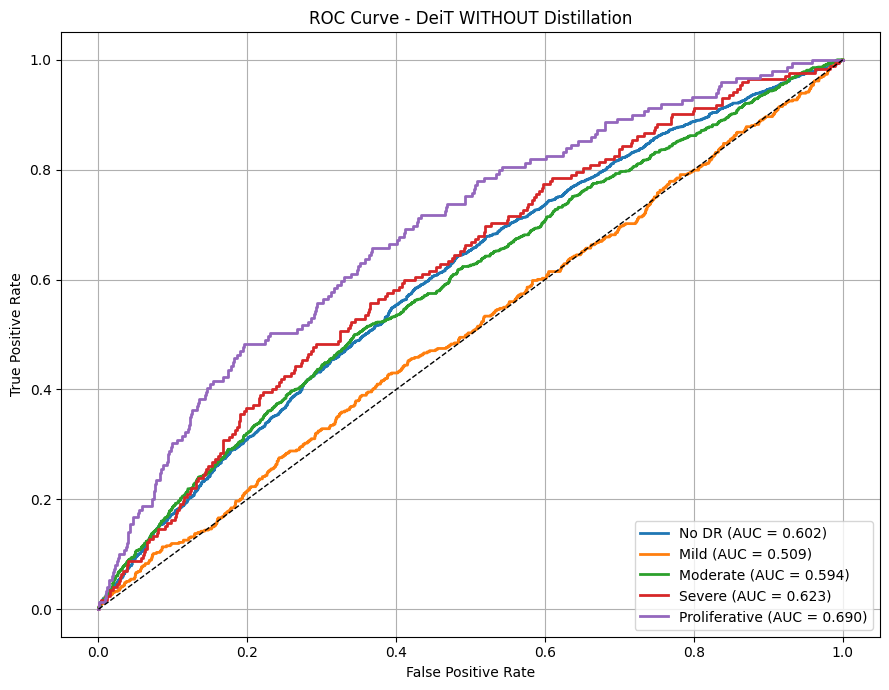

Saved ROC curve: SplitDATA/logs/roc_curves/roc_without_distillation.png


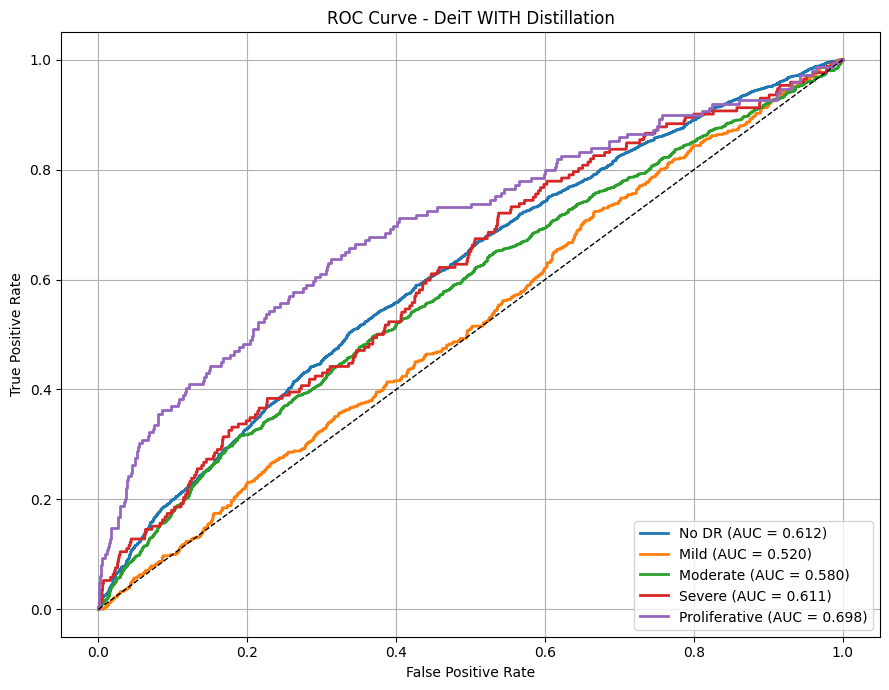

Saved ROC curve: SplitDATA/logs/roc_curves/roc_with_distillation.png


In [53]:
# ============================================================
# ROC CURVES FOR BOTH MODELS
# ============================================================

import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

os.makedirs("SplitDATA/logs/roc_curves", exist_ok=True)

def plot_multiclass_roc(
    test_labels,
    test_probs,
    class_names,
    title,
    save_path
):

    y_true_bin = label_binarize(
        test_labels,
        classes=[0,1,2,3,4]
    )

    n_classes = y_true_bin.shape[1]

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    plt.figure(figsize=(9, 7))

    for i in range(n_classes):

        fpr[i], tpr[i], _ = roc_curve(
            y_true_bin[:, i],
            test_probs[:, i]
        )

        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.plot(
            fpr[i],
            tpr[i],
            linewidth=2,
            label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
        )

    # random baseline
    plt.plot([0,1], [0,1], 'k--', linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(title)

    plt.legend(loc="lower right")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(save_path, dpi=300)

    plt.show()

    print(f"Saved ROC curve: {save_path}")


# ============================================================
# ROC CURVE - WITHOUT DISTILLATION
# ============================================================

plot_multiclass_roc(
    test_labels=baseline_results["labels"],
    test_probs=baseline_results["probs"],
    class_names=class_names,
    title="ROC Curve - DeiT WITHOUT Distillation",
    save_path="SplitDATA/logs/roc_curves/roc_without_distillation.png"
)


# ============================================================
# ROC CURVE - WITH DISTILLATION
# ============================================================

plot_multiclass_roc(
    test_labels=distilled_results["labels"],
    test_probs=distilled_results["probs"],
    class_names=class_names,
    title="ROC Curve - DeiT WITH Distillation",
    save_path="SplitDATA/logs/roc_curves/roc_with_distillation.png"
)

In [54]:
# ============================================================
# mAP / AVERAGE PRECISION + FINAL COMPARISON TABLE
# ============================================================

from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize
from IPython.display import display
import pandas as pd
import numpy as np
import os

os.makedirs("SplitDATA/logs", exist_ok=True)

# ============================================================
# FUNCTION: COMPUTE mAP
# ============================================================

def compute_map(
    test_labels,
    test_probs,
    class_names,
    model_name,
    save_path
):

    y_true_bin = label_binarize(
        test_labels,
        classes=[0, 1, 2, 3, 4]
    )

    n_classes = y_true_bin.shape[1]

    ap_per_class = []

    result_text = (
        f"====================================================\n"
        f"mAP RESULTS - {model_name}\n"
        f"====================================================\n\n"
    )

    print(f"\n{model_name}")

    for i in range(n_classes):

        ap = average_precision_score(
            y_true_bin[:, i],
            test_probs[:, i]
        )

        ap_per_class.append(ap)

        result_text += f"{class_names[i]} AP: {ap:.4f}\n"

        print(f"{class_names[i]} AP: {ap:.4f}")

    mAP = np.mean(ap_per_class)

    result_text += f"\nmAP: {mAP:.4f}\n"

    print(f"\nmAP: {mAP:.4f}")

    with open(save_path, "w") as f:
        f.write(result_text)

    print(f"Saved mAP results to: {save_path}")

    return {
        "ap_per_class": ap_per_class,
        "mAP": mAP
    }


# ============================================================
# mAP - WITHOUT DISTILLATION
# ============================================================

baseline_map_results = compute_map(
    test_labels=baseline_results["labels"],
    test_probs=baseline_results["probs"],
    class_names=class_names,
    model_name="DeiT WITHOUT Distillation",
    save_path="SplitDATA/logs/map_without_distillation.txt"
)


# ============================================================
# mAP - WITH DISTILLATION
# ============================================================

distilled_map_results = compute_map(
    test_labels=distilled_results["labels"],
    test_probs=distilled_results["probs"],
    class_names=class_names,
    model_name="DeiT WITH Distillation",
    save_path="SplitDATA/logs/map_with_distillation.txt"
)


# ============================================================
# SAVE FINAL mAP COMPARISON
# ============================================================

map_summary_path = "SplitDATA/logs/map_comparison_summary.txt"

summary_text = (
    "====================================================\n"
    "FINAL mAP COMPARISON\n"
    "====================================================\n\n"
    "DeiT WITHOUT Distillation\n"
    f"mAP: {baseline_map_results['mAP']:.4f}\n\n"
    "DeiT WITH Distillation\n"
    f"mAP: {distilled_map_results['mAP']:.4f}\n"
)

print(summary_text)

with open(map_summary_path, "w") as f:
    f.write(summary_text)

print(f"Saved mAP comparison summary to: {map_summary_path}")


# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "QWK",
        "MCC",
        "ROC-AUC OvR",
        "mAP"
    ],

    "DeiT WITHOUT Distillation": [
        baseline_results["accuracy"],
        baseline_results["balanced_accuracy"],
        baseline_results["macro_precision"],
        baseline_results["macro_recall"],
        baseline_results["macro_f1"],
        baseline_results["weighted_f1"],
        baseline_results["qwk"],
        baseline_results["mcc"],
        baseline_results["auc"] if baseline_results["auc"] is not None else np.nan,
        baseline_map_results["mAP"]
    ],

    "DeiT WITH Distillation": [
        distilled_results["accuracy"],
        distilled_results["balanced_accuracy"],
        distilled_results["macro_precision"],
        distilled_results["macro_recall"],
        distilled_results["macro_f1"],
        distilled_results["weighted_f1"],
        distilled_results["qwk"],
        distilled_results["mcc"],
        distilled_results["auc"] if distilled_results["auc"] is not None else np.nan,
        distilled_map_results["mAP"]
    ]
})

# Round values
comparison_df.iloc[:, 1:] = comparison_df.iloc[:, 1:].round(4)

print("\nFINAL MODEL COMPARISON TABLE\n")

display(
    comparison_df.style
    .set_caption("DeiT Comparison: Without vs With Distillation")
    .set_properties(**{
        "text-align": "center"
    })
)


# ============================================================
# SAVE FINAL COMPARISON TABLE
# ============================================================

table_csv_path = "SplitDATA/logs/final_comparison_table.csv"
table_txt_path = "SplitDATA/logs/final_comparison_table.txt"

comparison_df.to_csv(table_csv_path, index=False)

with open(table_txt_path, "w") as f:
    f.write("FINAL MODEL COMPARISON TABLE\n")
    f.write("====================================================\n\n")
    f.write(comparison_df.to_string(index=False))

print(f"Saved final comparison CSV to: {table_csv_path}")
print(f"Saved final comparison TXT to: {table_txt_path}")


DeiT WITHOUT Distillation
No DR AP: 0.7958
Mild AP: 0.0786
Moderate AP: 0.2084
Severe AP: 0.0390
Proliferative AP: 0.0477

mAP: 0.2339
Saved mAP results to: SplitDATA/logs/map_without_distillation.txt

DeiT WITH Distillation
No DR AP: 0.8042
Mild AP: 0.0733
Moderate AP: 0.1991
Severe AP: 0.0441
Proliferative AP: 0.0930

mAP: 0.2427
Saved mAP results to: SplitDATA/logs/map_with_distillation.txt
FINAL mAP COMPARISON

DeiT WITHOUT Distillation
mAP: 0.2339

DeiT WITH Distillation
mAP: 0.2427

Saved mAP comparison summary to: SplitDATA/logs/map_comparison_summary.txt

FINAL MODEL COMPARISON TABLE



,Metric,DeiT WITHOUT Distillation,DeiT WITH Distillation
0,Accuracy,0.099300,0.040000
1,Balanced Accuracy,0.236300,0.272100
2,Macro Precision,0.199300,0.028700
3,Macro Recall,0.236300,0.272100
4,Macro F1,0.073500,0.046900
5,Weighted F1,0.136600,0.010600
6,QWK,0.023700,0.019200
7,MCC,0.032500,0.017000
8,ROC-AUC OvR,0.603600,0.604200
9,mAP,0.233900,0.242700


Saved final comparison CSV to: SplitDATA/logs/final_comparison_table.csv
Saved final comparison TXT to: SplitDATA/logs/final_comparison_table.txt
